In [ ]:
#!pip install albumentations
#!pip install selectivesearch
# !pip uninstall opencv-contrib-python opencv-python
#!pip install opencv-contrib-python
#!pip install opencv-contrib-python --upgrade
from IPython.display import clear_output
clear_output(wait=True)

In [2]:
import albumentations as A
import os
import xml.etree.ElementTree as ET
import numpy as np
import cv2
import matplotlib.pyplot as plt
import glob
import torch
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import sys
import torchvision.datasets as datasets
from torch.utils.data import DataLoader
from PIL import Image, ImageDraw
from tqdm import tqdm
import selectivesearch
import pickle
import random

current_dir = os.getcwd()
print(current_dir)
sys.path.append(current_dir)

/Users/yun/Projects/02516-IDLCV/exe/exe3


In [3]:
class ProposalGenerator:
    def __init__(self):
        pass

    def selective_search_fast(self, image):
        # Convert BGR to RGB
        image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # Compute selective search proposals
        ss = cv2.ximgproc.segmentation.createSelectiveSearchSegmentation()
        ss.setBaseImage(image_rgb)
        ss.switchToSelectiveSearchFast()  # Use fast mode

        # Get proposals
        boxes = ss.process()

        # Convert to [x1, y1, x2, y2] format
        proposals = []
        for x, y, w, h in boxes:
            proposals.append([x, y, x+w, y+h])

        return proposals[:1500]

    def edge_boxes(self, image, max_boxes=1500, min_score=0.01):

        # Convert to RGB if necessary
        if len(image.shape) == 3 and image.shape[2] == 3:
            image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        else:
            image_rgb = image

        # Create edge boxes detector
        edge_boxes = cv2.ximgproc.createEdgeBoxes()
        edge_boxes.setMaxBoxes(max_boxes)
        edge_boxes.setMinScore(min_score)

        # Detect edges using Canny
        edges = cv2.Canny(image_rgb, 50, 150)
        edges = edges.astype(np.float32)  # Convert edge map to CV_32F
        orientation_map = np.zeros_like(edges, dtype=np.float32)  # Placeholder orientation map

        # Get bounding boxes
        boxes = edge_boxes.getBoundingBoxes(edges, orientation_map)[0]

        #Convert to [x1, y1, x2, y2] format and scale back
        proposals = []
        for box in boxes:
            x, y, w, h = box
            x = int(x)
            y = int(y)
            w = int(w)
            h = int(h)
            proposals.append([x, y, x+w, y+h])

        return proposals[:3000]

In [68]:
data_dir = '../../Potholes/annotated-images'

class ImageProcessor:
    def __init__(self, image_paths, label_paths, proposal_generator, transform = None, size = (256, 256)):
        self.image_paths = image_paths
        self.label_paths = label_paths
        self.proposal_generator = proposal_generator
        self.transform = transform
        self.size = size


    def generate_proposals(self, image, gt_boxes):
        proposals = self.proposal_generator(image)
        proposals = self.assign_labels(proposals, gt_boxes)

        return proposals

    def resize_gt_boxes(self, gt_boxes, scale):
        x_scale, y_scale = scale
        gt_boxes = [(x1 * x_scale, y1 * y_scale, x2 * x_scale, y2 * y_scale, c) for x1, y1, x2, y2, c in gt_boxes]
        return gt_boxes

    def assign_labels(self, proposals, gt_boxes, positive_iou_threshold=0.5, negative_iou_threshold=0.1):
      new_proposals = []
      for proposal in proposals:
          max_iou = 0.0
          assigned_label = 0  # Background class
          for gt_box in gt_boxes:
              iou = self.calculate_iou(proposal, gt_box)
              if iou > max_iou:
                  max_iou = iou
                  if iou >= positive_iou_threshold:
                      assigned_label = 1  # Object class label (assuming single class)
          if max_iou >= positive_iou_threshold or max_iou <= negative_iou_threshold:
              new_proposals.append([proposal[0], proposal[1], proposal[2], proposal[3], assigned_label])
          else:
              continue
              # Ignored sample
      return new_proposals

    def calculate_iou(self, box1, box2):
        x1 = max(box1[0], box2[0])
        y1 = max(box1[1], box2[1])
        x2 = min(box1[2], box2[2])
        y2 = min(box1[3], box2[3])

        intersection = max(0, x2 - x1) * max(0, y2 - y1)
        area1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
        area2 = (box2[2] - box2[0]) * (box2[3] - box2[1])

        union = area1 + area2 - intersection
        return intersection / union if union > 0 else 0

    def read_label_content(self, label_path):
        tree = ET.parse(label_path)
        root = tree.getroot()

        valid_boxes = []
        filename = root.find('filename').text
        for boxes in root.iter('object'):
            label = boxes.find("name").text
            ymin = int(boxes.find("bndbox/ymin").text)
            xmin = int(boxes.find("bndbox/xmin").text)
            ymax = int(boxes.find("bndbox/ymax").text)
            xmax = int(boxes.find("bndbox/xmax").text)

            # Check if the bounding box is valid
            # img-415 has a bug in the xml file
            # xmin = xmax.......
            # Potholes/annotated-images/img-415.xml: [xmin=273, ymin=164, xmax=273, ymax=165]
            if xmin >= xmax:
                # Optionally, log the invalid bounding box
                print(f"Invalid bbox in {label_path}: [xmin={xmin}, ymin={ymin}, xmax={xmax}, ymax={ymax}]")
                # continue  # Skip invalid bounding boxes
                xmin = xmax - 1
            if ymin >= ymax:
                # Optionally, log the invalid bounding box
                print(f"Invalid bbox in {label_path}: [xmin={xmin}, ymin={ymin}, xmax={xmax}, ymax={ymax}]")
                # continue  # Skip invalid bounding boxes
                ymin = ymax - 1

            valid_boxes.append([xmin, ymin, xmax, ymax, 1 if label == 'pothole' else 0])

        return valid_boxes, filename

    def process_image(self, idx):
        image_path = self.image_paths[idx]
        label_path = self.label_paths[idx]

        image = cv2.imread(image_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        gt_boxes, filename = self.read_label_content(label_path)
        if self.transform:
            transformed = self.transform(image=image, bboxes=gt_boxes)
            image = transformed['image']
            gt_boxes = transformed['bboxes']
        else:
            scale = (self.size[1] / image.shape[1], self.size[0] / image.shape[0])
            image = cv2.resize(image, self.size)
            gt_boxes = self.resize_gt_boxes(gt_boxes, scale)
        proposals = self.generate_proposals(image, gt_boxes)

        return {
            'filename': filename,
            'image': image,
            'image_path': image_path,
            'size': self.size,
            'gt_boxes': gt_boxes,
            'proposals': proposals,
        }

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        return self.process_image(idx)

def precompute_proposals_and_labels(image_processor, output_dir):
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)
    for image_data in tqdm(image_processor):
        filename = image_data['filename']
        with open(os.path.join(output_dir, f'samples_{filename}.pkl'), 'wb') as f:
            pickle.dump(image_data, f)

size = 256
transform = A.Compose([
        A.Resize(size, size),
        A.HorizontalFlip(p=0.5),
        A.ShiftScaleRotate(p=0.5),
        A.RandomBrightnessContrast(p=0.3),
        A.RGBShift(r_shift_limit=30, g_shift_limit=30, b_shift_limit=30, p=0.3),
    ],
    bbox_params=A.BboxParams(format='pascal_voc'),
)

image_paths =  sorted(glob.glob(data_dir + '/img-1.jpg'))
label_paths = sorted(glob.glob(data_dir + '/img-1.xml'))
processor = ImageProcessor(image_paths, label_paths, ProposalGenerator().selective_search_fast)
precompute_proposals_and_labels(processor, './test_proposals')

  0%|          | 0/1 [00:00<?, ?it/s]


ValueError: too many values to unpack (expected 4)

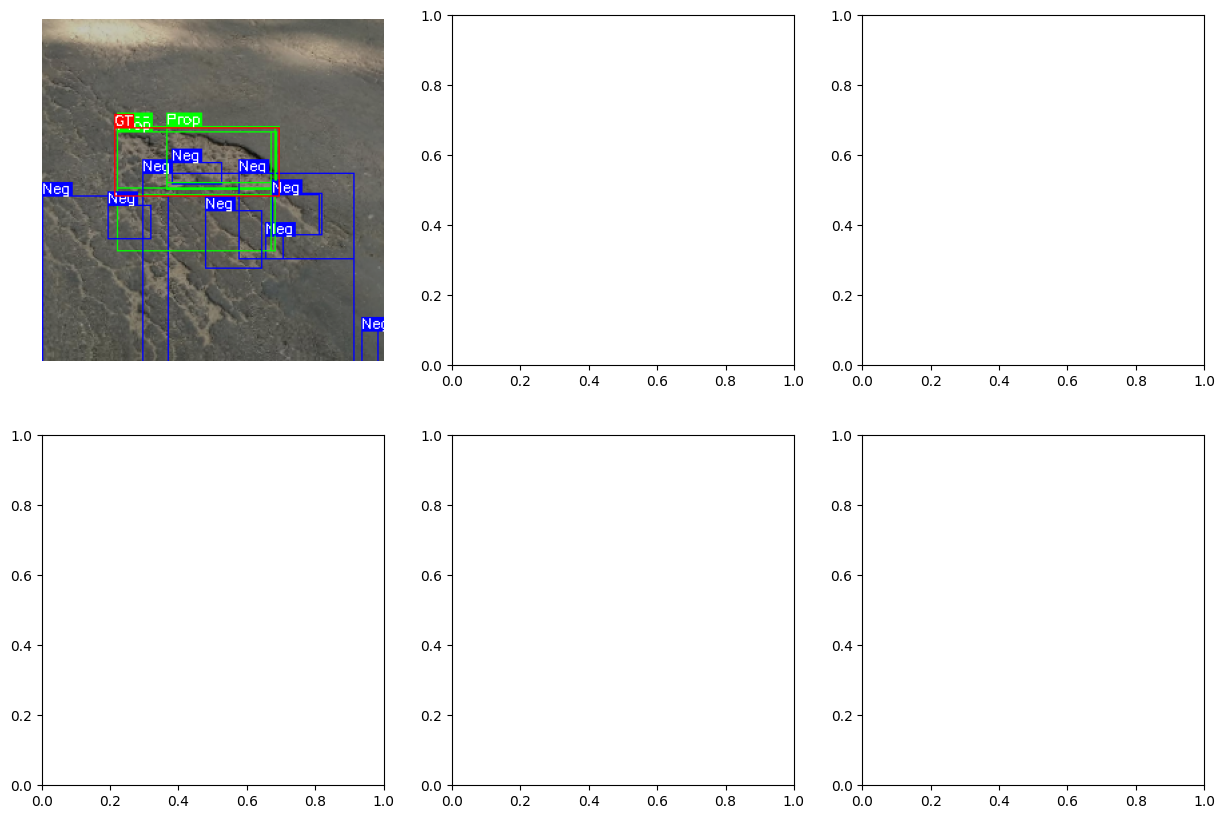

In [67]:
rate = 1
class ProposalDataset(torch.utils.data.Dataset):
    def __init__(self, samples_dir, type, num_samples = 10):
        self.samples = []
        self.num_samples = num_samples
        sample_files = sorted(glob.glob(os.path.join(samples_dir, 'samples_*.pkl')))

        train_idx = int(len(sample_files) * rate)
        valid_idx = int(len(sample_files) * (rate + (1 - rate) * 0.5))

        if type == 'train':
            self.sample_files = sample_files[:train_idx]
        elif type == 'valid':
            self.sample_files = sample_files[train_idx:valid_idx]
        elif type == 'test':
            self.sample_files = sample_files[valid_idx:]
        else:
            raise ValueError('Invalid type')

    def __len__(self):
        return len(self.sample_files)

    def __getitem__(self, idx):
        sample_file = self.sample_files[idx]

        sample = pickle.load(open(sample_file, 'rb'))
        # image_path = sample['image_path']
        image = sample['image']
        # gt_boxes = np.ones((len(sample['gt_boxes']), 5))
        gt_boxes = sample['gt_boxes']

        proposals = sample['proposals']
        positives = [p for p in proposals if p[4] == 1]
        negatives = [p for p in proposals if p[4] == 0]
        sampled_positives = random.sample(positives, min(len(positives), self.num_samples))
        sampled_negatives = random.sample(negatives, min(len(negatives), self.num_samples))
        sampled_proposals = sampled_positives + sampled_negatives
        random.shuffle(sampled_proposals)

        image = torch.tensor(sample['image'], dtype=torch.int)
        proposals = torch.tensor(np.array(sampled_proposals), dtype=torch.long)
        gt_boxes = torch.tensor(gt_boxes, dtype=torch.float)
        # print(transformed)
        return image, gt_boxes, proposals

def custom_collate_fn(batch):
    return tuple(zip(*batch))

batch_size = 10
trainset = ProposalDataset(type='train', samples_dir='./test_proposals')
# validset = ProposalDataset(transform=transform, type='valid', samples_dir='./test_proposals')
# testset = ProposalDataset(transform=transform, type='test', samples_dir='./test_proposals')

train_loader = DataLoader(trainset, batch_size=batch_size, shuffle=True, collate_fn=custom_collate_fn)
# valid_loader = DataLoader(validset, batch_size=batch_size, shuffle=False, collate_fn=custom_collate_fn)
# test_loader = DataLoader(testset, batch_size=batch_size, shuffle=False, collate_fn=custom_collate_fn)

TEXT_COLOR = (255, 255, 255) # White
GREEN_COLOR = (0, 255, 0) # GREEN
BLUE_COLOR = (0, 0, 255) # BLUE
RED_COLOR = (255, 0, 0) # RED

def visualize_bbox(img, bbox, class_name, color=RED_COLOR, thickness=2):
    """Visualizes a single bounding box on the image"""
    x_min, y_min, x_max, y_max = bbox
    x_min, x_max, y_min, y_max = int(x_min), int(x_max), int(y_min), int(y_max)
    cv2.rectangle(img, (x_min, y_min), (x_max, y_max), color=color, thickness=thickness)

    ((text_width, text_height), _) = cv2.getTextSize(class_name, cv2.FONT_HERSHEY_SIMPLEX, 0.35, 1)
    cv2.rectangle(img, (x_min, y_min - int(1.3 * text_height)), (x_min + text_width, y_min), color, -1)
    cv2.putText(
        img,
        text=class_name,
        org=(x_min, y_min - int(0.3 * text_height)),
        fontFace=cv2.FONT_HERSHEY_SIMPLEX,
        fontScale=0.35,
        color=TEXT_COLOR,
        lineType=cv2.LINE_AA,
    )
    return img

def visualize_proposals(img, ground_truth_boxes, proposals):
    img = img.copy()
    for proposal in proposals:
        box = proposal[:4]
        class_name = 'Prop' if proposal[4] == 1 else 'Neg'
        img = visualize_bbox(img, box, class_name, color=GREEN_COLOR if proposal[4] == 1 else BLUE_COLOR, thickness=1)
    for gt_box in ground_truth_boxes:
        img = visualize_bbox(img, gt_box[:4], 'GT', thickness=1)
    return img

images, gt_boxes, proposals = next(iter(train_loader))

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i in range(1):
    img = visualize_proposals(images[i].numpy(), gt_boxes[i].numpy(), proposals[i].numpy())
    axes[i].imshow(img)
    axes[i].axis('off')

plt.show()
